In [7]:
!pip install thefuzz python-Levenshtein

In [8]:
#All relevant imports for the notebook
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import requests
import datetime
from datetime import datetime
import sqlite3
import numpy as np
from scipy import stats
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from thefuzz import process
import geopandas as gpd
from shapely.geometry import Point


In [9]:
import pandas as pd
from pathlib import Path

# Use project-relative paths (works when cwd is project root; /src/ fails on Windows)
SRC = Path("src")
def _path(name):
    p = SRC / name
    if not p.exists() and "Arrests" in name and " (1)" not in name:
        alt = SRC / "NYPD_Arrests_Data__Historic_ (1).csv"
        return str(alt) if alt.exists() else str(p)
    return str(p)

airbnb_nyc_df = pd.read_csv(_path("AB_NYC_2019.csv"))
nypd_shooting_df = pd.read_csv(_path("NYPD_Shooting_Incident_Data__Historic_.csv"))
ny_tree_census_df = pd.read_csv(_path("new_york_tree_census_2015.csv"))
total_population_df = pd.read_csv(_path("Total Population.csv"), header=4)
arrest_data_df = pd.read_csv(_path("NYPD_Arrests_Data__Historic_.csv"))
nta_pop_df = pd.read_csv(_path("New_York_City_Population_By_Neighborhood_Tabulation_Areas.csv"))
nyc_gdf = gpd.read_file(_path("nycgeo.json"))
"""
display(ny_tree_census_df.head())
display(nypd_shooting_df.head())
display(airbnb_nyc_df.head())
display(Total_Population_df.head())
"""

FileNotFoundError: [Errno 2] No such file or directory: 'src/AB_NYC_2019.csv'

#**Most impactful factors affecting Airbnb pricing in New York City**

**Hypothesis: Greenery, Reviews, and Crime Rate affect Airbnb prices**

As Airbnb grows in popularity across the world, getting an accurate estimate of the price of Airbnbs will help new Airbnb owners to better price their houses. We will explore the relationship between various factors of the Airbnb and its price. We believe that crime rate, greenery around the borough and the reviews of the Airbnb will have the greatest impact on its price.

#**Data source identification and exploration(Prepare)**

In order to estimate the price of Airbnbs, we have extracted various data points such as room type, number of reviews, availability, boroughs, along with the three factors in our hypothesis. We have selected three datasets which are connected by the 5 types of boroughs in New York City.

List of datasets:
- [New York City Airbnb Open Data (2019) ](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)
- [NYPD Arrest Data (2006-2019) ](https://www.kaggle.com/datasets/thaddeussegura/nypd-arrest-data-20062019)
- [New York City Shooting Incident Dataset](https://www.kaggle.com/datasets/thaddeussegura/new-york-city-shooting-dataset)
- [Tree Census in New York City](https://www.kaggle.com/datasets/nycparks/tree-census)
- [Total Population in New York City](https://data.cccnewyork.org/data/map/97/total-population#97/a/3/147/132/a/a)

In [10]:
def map_coordinates_to_neighbourhood(df):
    import geopandas as gpd
    import pandas as pd

    temp_df = df.copy()

    # Detect latitude / longitude columns case-insensitively.
    lower_to_original = {c.lower(): c for c in temp_df.columns}
    lat_col = lower_to_original.get('latitude')
    lon_col = lower_to_original.get('longitude')

    if lat_col is None or lon_col is None:
        raise ValueError("Input dataframe must contain latitude/longitude columns.")

    # Coerce to numeric and keep only valid coordinate rows for spatial join.
    temp_df[lat_col] = pd.to_numeric(temp_df[lat_col], errors='coerce')
    temp_df[lon_col] = pd.to_numeric(temp_df[lon_col], errors='coerce')
    valid_mask = (
        temp_df[lat_col].between(-90, 90)
        & temp_df[lon_col].between(-180, 180)
        & temp_df[lat_col].notna()
        & temp_df[lon_col].notna()
    )

    valid_df = temp_df.loc[valid_mask].copy()

    # Initialize neighbourhood to preserve original row count/order.
    temp_df['neighbourhood'] = pd.NA
    if valid_df.empty:
        return temp_df

    gdf = gpd.GeoDataFrame(
        valid_df,
        geometry=gpd.points_from_xy(valid_df[lon_col], valid_df[lat_col]),
        crs='EPSG:4326',
    )

    nyc_gdf_local = nyc_gdf[['geometry', 'NTAName']].copy()
    if nyc_gdf_local.crs is None:
        nyc_gdf_local = nyc_gdf_local.set_crs('EPSG:4326')
    elif nyc_gdf_local.crs.to_string() != 'EPSG:4326':
        nyc_gdf_local = nyc_gdf_local.to_crs('EPSG:4326')

    joined = gpd.sjoin(gdf, nyc_gdf_local, how='left', predicate='within')

    mapped = fuzzy_map_neighbourhood(joined, 'NTAName')
    temp_df.loc[mapped.index, 'neighbourhood'] = mapped['neighbourhood']

    return temp_df


def fuzzy_map_neighbourhood(df, target_column):
    from thefuzz import process

    temp_df = df.copy()
    airbnb_unique_hoods = airbnb_nyc_df['neighbourhood'].dropna().unique().tolist()

    source_hoods = temp_df[target_column].dropna().unique().tolist()

    fuzz_map = {}
    for hood in source_hoods:
        match, score = process.extractOne(hood, airbnb_unique_hoods)
        fuzz_map[hood] = match if score >= 75 else None

    temp_df['neighbourhood'] = temp_df[target_column].map(fuzz_map)
    return temp_df

### DS1: New York City Airbnb Open Data(2019)

Description: The NYC Airbnb Open Data dataset, downloaded on 28/01/2026, contains detailed listing activity and metrics including geographical locations, prices, and room types across New York City. Specifically, it provides neighbourhood_group (the five boroughs) and neighbourhood data, which offer an ideal level of granularity for analyzing market density and local pricing trends. The dataset also includes the last_review date, allowing for temporal analysis of listing popularity and guest activity. The following code imports the data into a DataFrame and displays the first few rows to illustrate the structure of the rental market data.

In [11]:
#We first take a look at the firsst 5 rows of the dataset
airbnb_nyc_df.head()
airbnb_nyc_df.info()

NameError: name 'airbnb_nyc_df' is not defined

In [12]:
description_df = airbnb_nyc_df[['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']].describe().round(1)
description_df = description_df.transpose()
description_df = description_df.rename(columns={
    'count': 'Number of Listings',
    'mean': 'Average Value',
    'std': 'Standard Deviation',
    'min': 'Minimum Value',
    '25%': '25th Percentile',
    '50%': 'Median Value',
    '75%': '75th Percentile',
    'max': 'Maximum Value'
})
display(description_df)

NameError: name 'airbnb_nyc_df' is not defined

In [ ]:
# Check for total number of null values for each column
#
empty_records = airbnb_nyc_df.isnull().sum()
empty_records[empty_records > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

In [ ]:
def clean_neighbourhood_keep_coop(value):
    if pd.isna(value):
        return pd.NA
    s = str(value).strip()
    primary = s.split(',')[0].strip()
    if primary.lower() == 'co-op city':
        return 'Co-op City'
    return primary.split('-')[0].strip()

# Distance utility reused in downstream cells.
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dlon / 2.0) ** 2)
    return 2 * R * np.arcsin(np.sqrt(a))

# Keep all neighbourhoods, including Co-op City.
airbnb_nyc_df['neighbourhood'] = airbnb_nyc_df['neighbourhood'].apply(clean_neighbourhood_keep_coop)
average_price_by_neighbourhood = airbnb_nyc_df.groupby('neighbourhood')['price'].mean().reset_index()

# Compute CBD distance for each listing only (no correlation in this cell).
airbnb_nyc_df['latitude'] = pd.to_numeric(airbnb_nyc_df['latitude'], errors='coerce')
airbnb_nyc_df['longitude'] = pd.to_numeric(airbnb_nyc_df['longitude'], errors='coerce')

times_sq = (40.7580, -73.9855)
lower_manhattan = (40.7075, -74.0113)

airbnb_nyc_df['dist_to_times_sq_km'] = haversine_km(
    airbnb_nyc_df['latitude'].to_numpy(),
    airbnb_nyc_df['longitude'].to_numpy(),
    times_sq[0],
    times_sq[1],
)
airbnb_nyc_df['dist_to_lower_manhattan_km'] = haversine_km(
    airbnb_nyc_df['latitude'].to_numpy(),
    airbnb_nyc_df['longitude'].to_numpy(),
    lower_manhattan[0],
    lower_manhattan[1],
)
airbnb_nyc_df['dist_to_cbd_min_km'] = airbnb_nyc_df[['dist_to_times_sq_km', 'dist_to_lower_manhattan_km']].min(axis=1)

# Keep neighbourhood-level CBD table available for neighbourhood correlation cell.
cbd_distance_by_neighbourhood = (
    airbnb_nyc_df[['neighbourhood', 'dist_to_cbd_min_km']]
    .dropna(subset=['neighbourhood', 'dist_to_cbd_min_km'])
    .groupby('neighbourhood', as_index=False)['dist_to_cbd_min_km']
    .mean()
)

print('Computed dist_to_cbd_min_km for Airbnb listings.')
print(f'Listings with CBD distance: {airbnb_nyc_df["dist_to_cbd_min_km"].notna().sum()}')
display(airbnb_nyc_df[['neighbourhood', 'price', 'dist_to_cbd_min_km']].head(20))

Computed dist_to_cbd_min_km for Airbnb listings.
Listings with CBD distance: 48895


,neighbourhood,price,dist_to_cbd_min_km
0,Kensington,149,7.436667
1,Midtown,225,0.508366
2,Harlem,150,6.757240
3,Clinton Hill,89,5.006161
4,East Harlem,80,5.701496
5,Murray Hill,200,1.449704
6,Bedford,60,5.198369
7,Hell's Kitchen,79,0.767636
8,Upper West Side,79,5.105387
9,Chinatown,150,1.883729


In [ ]:
airbnb_nyc_df['neighbourhood'].nunique()

220

### DS2: New York City Shooting Incident(2019)

Description: The Kaggle dataset, focusing on historic shooting incidents, provides a detailed log of public safety events including the exact date, time, and geographic coordinates of each occurrence in 2019. More precisely, borough-level data, which offers the granularity that we require. This allows for the creation of "safety proximity" features that can significantly influence localized pricing models. The following code imports the data into a DataFrame and displays the first few rows, offering an initial look at the incident reports and their spatial attributes.

In [ ]:
nypd_shooting_df.head()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,PRECINCT,JURISDICTION_CODE,LOCATION_DESC,STATISTICAL_MURDER_FLAG,PERP_AGE_GROUP,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,74146165,08/14/2010,3:11:00,QUEENS,113,0.0,NaN,False,NaN,NaN,NaN,25-44,M,BLACK,1046573,183057,40.668915,-73.775341,POINT (-73.77534099699994 40.66891477200004)
1,66928846,10/17/2009,18:03:00,BROOKLYN,67,0.0,NaN,True,NaN,NaN,NaN,45-64,M,BLACK,1003313,176413,40.650877,-73.931302,POINT (-73.93130224699998 40.65087729100002)
2,29114164,05/18/2007,23:00:00,BROOKLYN,75,0.0,NaN,False,NaN,NaN,NaN,25-44,M,BLACK,1016292,176228,40.650332,-73.884529,POINT (-73.884529479 40.65033205800006)
3,85180336,06/09/2012,17:15:00,BROOKLYN,81,0.0,NaN,False,NaN,NaN,NaN,25-44,M,BLACK,1005597,188673,40.684523,-73.923032,POINT (-73.92303235699995 40.68452304300007)
4,73405770,06/27/2010,4:14:00,BRONX,47,0.0,NaN,False,NaN,NaN,NaN,25-44,M,BLACK,1023551,263366,40.889474,-73.857860,POINT (-73.85786021699995 40.88947350500007)


In [ ]:
nypd_shooting_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21626 entries, 0 to 21625
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             21626 non-null  int64  
 1   OCCUR_DATE               21626 non-null  str    
 2   OCCUR_TIME               21626 non-null  str    
 3   BORO                     21626 non-null  str    
 4   PRECINCT                 21626 non-null  int64  
 5   JURISDICTION_CODE        21624 non-null  float64
 6   LOCATION_DESC            9265 non-null   str    
 7   STATISTICAL_MURDER_FLAG  21626 non-null  bool   
 8   PERP_AGE_GROUP           14321 non-null  str    
 9   PERP_SEX                 14355 non-null  str    
 10  PERP_RACE                14355 non-null  str    
 11  VIC_AGE_GROUP            21626 non-null  str    
 12  VIC_SEX                  21626 non-null  str    
 13  VIC_RACE                 21626 non-null  str    
 14  X_COORD_CD               21626 no

In [ ]:
total_population_df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Location,TimeFrame,DataFormat,Data,Fips
1,Battery Park/Tribeca,2005,Number,51150.45963,101
2,Greenwich Village,2005,Number,75508.54037,102
3,Lower East Side,2005,Number,145556,103
4,Chelsea/Clinton,2005,Number,88754.39184,104


In [ ]:
nypd_shooting_df = map_coordinates_to_neighbourhood(nypd_shooting_df)

In [ ]:
# Keep only shooting records from 2015 to 2019
shooting_2015_2019 = nypd_shooting_df.copy()
shooting_2015_2019['OCCUR_DATE'] = pd.to_datetime(
    shooting_2015_2019['OCCUR_DATE'],
    errors='coerce'
 )
shooting_2015_2019 = shooting_2015_2019[
    shooting_2015_2019['OCCUR_DATE'].dt.year.between(2015, 2019)
 ]

# Calculate value counts for each matched neighborhood
incident_counts = shooting_2015_2019['neighbourhood'].value_counts().reset_index()
incident_counts.columns = ['neighbourhood', 'incident_count']

# Display the top 20 neighborhoods by incident count
display(incident_counts.head(20))

,neighbourhood,incident_count
0,Harlem,400
1,East New York,270
2,Crown Heights,255
3,Brownsville,191
4,Mott Haven,171
5,Stuyvesant Town,160
6,Bedford,160
7,Tremont,150
8,Flatbush,139
9,West Village,130


In [ ]:
# 1. Prepare unique Airbnb neighborhoods (including Co-op City)
airbnb_unique_hoods = airbnb_nyc_df['neighbourhood'].dropna().unique().tolist()

# 2. Extract NTA population reference (Year 2010)
nta_2010 = nta_pop_df[nta_pop_df['Year'] == 2010].groupby('NTA Name')['Population'].sum().reset_index()
nta_names = nta_2010['NTA Name'].tolist()

# 3. Perform Fuzzy Matching (75% threshold)
mapping_results = []
for hood in airbnb_unique_hoods:
    match, score = process.extractOne(hood, nta_names)
    pop_val = nta_2010.loc[nta_2010['NTA Name'] == match, 'Population'].values[0] if score >= 75 else None
    mapping_results.append({'Airbnb Neighbourhood': hood, 'Population (2010 Census)': pop_val})

# 4. Create and display the final mapping table
airbnb_pop_map_df = pd.DataFrame(mapping_results).sort_values('Airbnb Neighbourhood')

print(f'Created population mapping for {len(airbnb_pop_map_df)} neighborhoods.')
display(airbnb_pop_map_df.head(20))

Created population mapping for 220 neighborhoods.


,Airbnb Neighbourhood,Population (2010 Census)
69,Allerton,28903.0
214,Arden Heights,25238.0
86,Arrochar,16079.0
106,Arverne,36885.0
56,Astoria,78793.0
197,Bath Beach,29931.0
101,Battery Park City,39699.0
90,Bay Ridge,79371.0
140,Bay Terrace,21751.0
187,Baychester,34517.0


In [ ]:
# 1. Merge incident counts with the population mapping
# airbnb_pop_map_df contains the population per Airbnb neighbourhood
# incident_counts contains total shootings per airbnb_matched_neighbourhood

neighbourhood_stats = incident_counts.merge(
    airbnb_pop_map_df,
    left_on='neighbourhood',
    right_on='Airbnb Neighbourhood',
    how='inner'
)

# 2. Calculate shootings per 10,000 people for 2015-2019
# We ensure we don't divide by zero and only include valid population data
neighbourhood_stats = neighbourhood_stats[neighbourhood_stats['Population (2010 Census)'] > 0]

neighbourhood_stats['shootings_per_10000_2015_2019'] = (
    neighbourhood_stats['incident_count'] / neighbourhood_stats['Population (2010 Census)']
) * 10000

# 3. Sort by the new metric
neighbourhood_stats = neighbourhood_stats.sort_values(by='shootings_per_10000_2015_2019', ascending=False)

# Display the top results
print("Neighborhoods with the highest shooting density (per 10,000 residents) from 2015 to 2019:")
display(neighbourhood_stats[['neighbourhood', 'incident_count', 'Population (2010 Census)', 'shootings_per_10000_2015_2019']].head(20))

Neighborhoods with the highest shooting density (per 10,000 residents) from 2015 to 2019:


,neighbourhood,incident_count,Population (2010 Census),shootings_per_10000_2015_2019
5,Stuyvesant Town,160,21049.0,76.013112
0,Harlem,400,75282.0,53.133551
16,Prospect,91,19849.0,45.846138
4,Mott Haven,171,39214.0,43.606875
18,Lighthouse Hill,80,22887.0,34.954341
7,Tremont,150,43423.0,34.543905
3,Brownsville,191,58300.0,32.761578
1,East New York,270,91958.0,29.361230
2,Crown Heights,255,103169.0,24.716727
25,Springfield Gardens,59,25409.0,23.220119


### DS3 and DS4: NYPD Arrest Data and Total Population

Description for NYPD Arrest Data: The Kaggle dataset, encompassing historic NYPD arrest records from 2006 to 2024, provides a comprehensive record of every arrest effected in New York City. This dataset includes highly specific geospatial coordinates and other markers such as date and time, which are vital for a long-term analysis of neighborhood safety evolution. More precisely, it contains the borough and precinct, which are at the exact level of granularity required. For our Airbnb smart pricing project, this allows us to track how the safety profile of a specific borough and its market value—has shifted over nearly two decades. The following code imports the data into a DataFrame and displays the first few rows, highlighting the offense categories and location descriptors used in our predictive model.

Description for Total Population Data: The provided dataset, sourced from the U.S. Census Bureau, contains historic Total Population figures for New York City across various years, including our target year of 2019. The data is organized by Location, providing the borough-level granularity necessary to analyze market density and demand. This allows for a more nuanced understanding of Airbnb pricing by enabling us to calculate "per capita" metrics for crime or amenity availability. The following code imports the data into a DataFrame and displays the first few rows, showing the population counts and the specific community districts or neighborhoods covered.

In [ ]:
arrest_data_df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,10837169,04/02/2006,NaN,NaN,NaN,NaN,NaN,NaN,Q,101,0.0,NaN,M,BLACK,1051775.0,159727.0,40.604841,-73.756823,POINT (-73.75682250899997 40.604840985000074)
1,189797412,11/09/2018,475.0,NaN,NaN,NaN,PL 1651601,M,M,28,1.0,25-44,F,WHITE HISPANIC,997374.0,234664.0,40.810773,-73.952592,POINT (-73.95259158999993 40.81077276700007)
2,189992103,11/14/2018,475.0,NaN,NaN,NaN,PL 1651601,M,K,75,1.0,18-24,M,BLACK,1021568.0,185710.0,40.676337,-73.865464,POINT (-73.86546353999995 40.676337363000066)
3,189714430,11/07/2018,117.0,RECKLESS ENDANGERMENT 1,126.0,MISCELLANEOUS PENAL LAW,PL 1202500,F,M,26,0.0,45-64,M,WHITE,993685.0,233346.0,40.807160,-73.965920,POINT (-73.96591978699998 40.80715993100006)
4,190067816,11/15/2018,586.0,NaN,NaN,NaN,PL 230341A,F,M,5,0.0,18-24,M,BLACK,984946.0,200203.0,40.716196,-73.997491,POINT (-73.99749074599998 40.716195914000025)


In [ ]:
arrest_data_df.describe()

,ARREST_KEY,PD_CD,KY_CD,ARREST_PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,5.012956e+06,5.012695e+06,5.003927e+06,5.012956e+06,5.012946e+06,5.012955e+06,5.012955e+06,5.012955e+06,5.012955e+06
mean,9.579149e+07,5.117004e+02,3.016261e+02,6.062439e+01,1.304714e+00,1.005357e+06,2.149659e+05,4.075649e+01,-7.392378e+01
std,5.222361e+07,2.633719e+02,1.817349e+02,3.430862e+01,9.427788e+00,1.999599e+04,1.648721e+05,4.456872e-01,7.216800e-02
min,9.926901e+06,0.000000e+00,1.010000e+02,1.000000e+00,0.000000e+00,9.133570e+05,1.211310e+05,4.049891e+01,-7.425494e+01
25%,5.931854e+07,2.930000e+02,1.260000e+02,3.300000e+01,0.000000e+00,9.933700e+05,1.868860e+05,4.067957e+01,-7.396707e+01
50%,8.345894e+07,5.110000e+02,3.410000e+02,6.000000e+01,0.000000e+00,1.004890e+06,2.094910e+05,4.074166e+01,-7.392549e+01
75%,1.435467e+08,7.500000e+02,3.480000e+02,8.400000e+01,0.000000e+00,1.015835e+06,2.366140e+05,4.081609e+01,-7.388586e+01
max,2.068936e+08,9.970000e+02,9.950000e+02,1.230000e+02,9.700000e+01,1.067302e+06,8.202360e+06,6.208307e+01,-7.368178e+01


In [ ]:
arrest_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5012956 entries, 0 to 5012955
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ARREST_KEY         int64  
 1   ARREST_DATE        str    
 2   PD_CD              float64
 3   PD_DESC            str    
 4   KY_CD              float64
 5   OFNS_DESC          str    
 6   LAW_CODE           str    
 7   LAW_CAT_CD         str    
 8   ARREST_BORO        str    
 9   ARREST_PRECINCT    int64  
 10  JURISDICTION_CODE  float64
 11  AGE_GROUP          str    
 12  PERP_SEX           str    
 13  PERP_RACE          str    
 14  X_COORD_CD         float64
 15  Y_COORD_CD         float64
 16  Latitude           float64
 17  Longitude          float64
 18  Lon_Lat            str    
dtypes: float64(7), int64(2), str(10)
memory usage: 726.7 MB


In [ ]:
total_population_df[5:].info()

<class 'pandas.DataFrame'>
RangeIndex: 3081 entries, 5 to 3085
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  3081 non-null   str  
 1   Unnamed: 1  3081 non-null   str  
 2   Unnamed: 2  3081 non-null   str  
 3   Unnamed: 3  3081 non-null   str  
 4   Unnamed: 4  3081 non-null   str  
dtypes: str(5)
memory usage: 120.5 KB


In [ ]:
total_population_df = pd.read_csv(str(Path("src") / "Total Population.csv"), header=4)
total_population_df.columns = total_population_df.iloc[0]
total_population_df = total_population_df[1:].reset_index(drop=True)
total_population_df = total_population_df.rename(columns={
    'Location': 'Borough',
    'TimeFrame': 'Year',
    'Data': 'Population'
})
total_population_df['Year'] = pd.to_numeric(total_population_df['Year'])
total_population_df['Population'] = pd.to_numeric(total_population_df['Population'])
target_boroughs = ['Manhattan', 'Queens', 'Brooklyn', 'Bronx', 'Staten Island']
target_years = range(2015, 2020)
filtered_population = total_population_df[
    (total_population_df['Borough'].isin(target_boroughs)) &
    (total_population_df['Year'].isin(target_years))
]
display(filtered_population[['Borough', 'Year', 'Population']])

,Borough,Year,Population
1655,Bronx,2015,1455444.0
1656,Brooklyn,2015,2636735.0
1657,Manhattan,2015,1644518.0
1658,Queens,2015,2339150.0
1659,Staten Island,2015,474558.0
1946,Bronx,2016,1455720.0
1947,Brooklyn,2016,2629150.0
1948,Manhattan,2016,1643734.0
1949,Queens,2016,2333054.0
1950,Staten Island,2016,476015.0


In [ ]:
# Arrest density per 10,000 residents, by year
# NYPD arrests dataset uses these coordinate columns: 'Latitude' and 'Longitude'.
arrest_cols_needed = ['ARREST_DATE', 'Latitude', 'Longitude']
arrest_input = arrest_data_df[arrest_cols_needed].copy()

print("Mapping arrests to neighbourhood using Latitude/Longitude...")
arrest_mapped = map_coordinates_to_neighbourhood(arrest_input)
arrest_mapped = arrest_mapped.dropna(subset=['neighbourhood']).copy()

# 1. Parse ARREST_DATE to extract year
arrest_mapped['year'] = pd.to_datetime(arrest_mapped['ARREST_DATE'], format='%m/%d/%Y', errors='coerce').dt.year
arrest_mapped = arrest_mapped.dropna(subset=['year'])
arrest_mapped['year'] = arrest_mapped['year'].astype(int)

# 2. Count arrests per neighbourhood per year
arrest_counts_by_year = arrest_mapped.groupby(['neighbourhood', 'year']).size().reset_index(name='arrest_count')

# 3. Merge with population (2010 Census) for density calculation
arrest_density_by_year = arrest_counts_by_year.merge(
    airbnb_pop_map_df,
    left_on='neighbourhood',
    right_on='Airbnb Neighbourhood',
    how='inner'
)
arrest_density_by_year = arrest_density_by_year[arrest_density_by_year['Population (2010 Census)'] > 0]
arrest_density_by_year['arrests_per_10000'] = (
    arrest_density_by_year['arrest_count'] / arrest_density_by_year['Population (2010 Census)']
) * 10000

# 4. Display summary: top neighbourhoods by arrests_per_10000 (averaged across years)
arrest_summary = arrest_density_by_year.groupby('neighbourhood').agg(
    total_arrests=('arrest_count', 'sum'),
    mean_arrests_per_10000=('arrests_per_10000', 'mean'),
    years_covered=('year', 'nunique')
).reset_index().sort_values('mean_arrests_per_10000', ascending=False)

print("Arrest density by neighbourhood (mean arrests per 10,000 residents across years):")
display(arrest_summary.head(20))
print("\nArrest density by neighbourhood and year:")
display(arrest_density_by_year[['neighbourhood', 'year', 'arrest_count', 'Population (2010 Census)', 'arrests_per_10000']].head(25))

Mapping arrests to neighbourhood using Latitude/Longitude...
Arrest density by neighbourhood (mean arrests per 10,000 residents across years):


,neighbourhood,total_arrests,mean_arrests_per_10000,years_covered
88,Midtown,178694,4458.210668,14
67,Harlem,333063,3160.146421,14
92,Mott Haven,139682,2544.317263,14
120,Stuyvesant Town,61767,2096.027636,14
71,Hunts Point,69725,1830.744428,14
32,Clinton Hill,83064,1705.367152,14
132,Washington Heights,156474,1664.787042,14
74,Jamaica,120199,1597.299186,14
103,Prospect,43116,1551.571508,14
80,Lighthouse Hill,44856,1399.921353,14



Arrest density by neighbourhood and year:


,neighbourhood,year,arrest_count,Population (2010 Census),arrests_per_10000
0,Allerton,2006,492,28903.0,170.224544
1,Allerton,2007,523,28903.0,180.950074
2,Allerton,2008,498,28903.0,172.300453
3,Allerton,2009,612,28903.0,211.742726
4,Allerton,2010,644,28903.0,222.814241
5,Allerton,2011,631,28903.0,218.316438
6,Allerton,2012,595,28903.0,205.860983
7,Allerton,2013,815,28903.0,281.977649
8,Allerton,2014,725,28903.0,250.839013
9,Allerton,2015,644,28903.0,222.814241


In [ ]:
arrest_density_2015_2019 = arrest_density_by_year[
    arrest_density_by_year['year'].between(2015, 2019)
].copy()

arrest_density_2015_2019['arrests_per_1000'] = (
    arrest_density_2015_2019['arrests_per_10000'] / 10
 )

mean_arrests_per_1000 = (
    arrest_density_2015_2019
    .groupby('neighbourhood', as_index=False)['arrests_per_1000']
    .mean()
    .rename(columns={'arrests_per_1000': 'mean_arrests_per_1000'})
    .sort_values('mean_arrests_per_1000', ascending=False)
 )

# Keep typo-compatible alias if referenced elsewhere.
mena_arrests_per_1000 = mean_arrests_per_1000

print('Mean arrests per 1,000 residents (2015-2019):')
display(mean_arrests_per_1000.head(20))

Mean arrests per 1,000 residents (2015-2019):


,neighbourhood,mean_arrests_per_1000
88,Midtown,348.250087
67,Harlem,229.295183
92,Mott Haven,216.050390
116,Springfield Gardens,147.798024
71,Hunts Point,144.339068
32,Clinton Hill,142.301170
120,Stuyvesant Town,135.417359
74,Jamaica,122.457257
103,Prospect,122.051489
17,Boerum Hill,120.568198


#**DS 5 Tree Census**

Description: The 2015 NYC Street Tree Census dataset, a landmark "citizen science" project known as TreesCount!, provides a comprehensive digital inventory of 666,134 street trees mapped across all five boroughs. This dataset is organized by individual tree records and can be organised by borough level. More precisely, it contains qualitative assessments of tree health and stewardship, which serve as proxies for neighborhood maintenance and resident engagement at the exact level of granularity required to categorize listings by street-level appeal.For our smart pricing project, this allows us to track how the density of trees in a specific boroughcan affect property prices. The following code imports the data into a DataFrame and displays the first few rows, showing the diameter at breast height (tree_dbh) and environmental indicators used in our predictive model.

In [ ]:
# 1. Apply fuzzy mapping to align tree census 'nta_name' with Airbnb neighborhoods
# Note: 'nta_name' is the target column in ny_tree_census_df
tree_census_mapped = fuzzy_map_neighbourhood(ny_tree_census_df, 'nta_name')

# 2. Keep all matched neighbourhood records that meet the 75% threshold
tree_census_mapped = tree_census_mapped[tree_census_mapped['neighbourhood'].notnull()]

# 3. Calculate total number of trees per matched neighborhood
tree_counts_per_neighborhood = tree_census_mapped.groupby('neighbourhood').size().reset_index(name='total_trees')

# 4. Sort and display the results
tree_counts_per_neighborhood = tree_counts_per_neighborhood.sort_values(by='total_trees', ascending=False)
display(tree_counts_per_neighborhood.head(20))

,neighbourhood,total_trees
74,Jamaica,15861
99,Park Slope,13128
51,Eltingville,12969
47,East New York,12598
56,Flushing,11459
67,Harlem,10790
65,Great Kills,10734
9,Bayside,9780
135,West Village,9548
143,Woodrow,9251


In [ ]:
# 1. Load and project GeoJSON for accurate area calculation
if 'nyc_gdf' not in globals():
    nyc_gdf = gpd.read_file(str(Path("src") / "nycgeo.json"))

nyc_projected = nyc_gdf.to_crs(epsg=2263)
nyc_projected['area_sq_miles'] = nyc_projected['geometry'].area / (5280**2)

# 2. Extract area data
raw_area_df = nyc_projected[['NTAName', 'area_sq_miles']].copy()

# 3. Apply fuzzy mapping to align with Airbnb neighborhoods
# We use the previously defined fuzzy_map_neighbourhood function
mapped_area_df = fuzzy_map_neighbourhood(raw_area_df, 'NTAName')

# 4. Clean up: Remove records that didn't match and aggregate area
# (In case multiple NTAs map to the same Airbnb neighborhood)
neighborhood_area_df = mapped_area_df.dropna(subset=['neighbourhood'])
neighborhood_area_df = neighborhood_area_df.groupby('neighbourhood')['area_sq_miles'].sum().reset_index()

# 5. Display the results
print("Square Area mapped to Airbnb Neighborhoods:")
display(neighborhood_area_df.sort_values(by='area_sq_miles', ascending=False).head(20))

Square Area mapped to Airbnb Neighborhoods:


,neighbourhood,area_sq_miles
99,Park Slope,34.378008
95,New Springville,11.736441
52,Emerson Hill,6.632073
74,Jamaica,5.714650
125,Tottenville,5.220325
51,Eltingville,5.064445
47,East New York,4.893792
56,Flushing,3.807754
121,Sunnyside,3.674021
12,Belle Harbor,3.573575


In [ ]:
# Tree density per neighbourhood (trees per square mile)
tree_density_df = tree_counts_per_neighborhood.merge(
    neighborhood_area_df,
    on='neighbourhood',
    how='inner'
)

# Avoid divide-by-zero
tree_density_df = tree_density_df[tree_density_df['area_sq_miles'] > 0]

tree_density_df['trees_per_sq_mile'] = (
    tree_density_df['total_trees'] / tree_density_df['area_sq_miles']
)

tree_density_df = tree_density_df.sort_values('trees_per_sq_mile', ascending=False)

print('Tree density by neighbourhood (trees per sq mile):')
display(tree_density_df[['neighbourhood', 'total_trees', 'area_sq_miles', 'trees_per_sq_mile']].head(20))

Tree density by neighbourhood (trees per sq mile):


,neighbourhood,total_trees,area_sq_miles,trees_per_sq_mile
57,Upper East Side,4673,0.719746,6492.566472
126,Brooklyn Heights,1767,0.358157,4933.586195
35,Upper West Side,5881,1.233211,4768.850541
142,Fordham,1060,0.226300,4684.051095
110,Windsor Terrace,2290,0.503683,4546.508783
141,Gramercy,1172,0.269959,4341.407016
60,Glendale,4509,1.076703,4187.783026
134,Prospect Heights,1535,0.367248,4179.737435
131,Longwood,1572,0.385464,4078.206320
130,East Village,1575,0.390902,4029.138080


## Joining the datasets

In [ ]:
# 1) Average Airbnb price by neighbourhood
price_df = average_price_by_neighbourhood[['neighbourhood', 'price']].copy()
price_df = price_df.rename(columns={'price': 'average_price'})

# 2) Shootings per 10,000 residents from 2015 to 2019 (compute if not precomputed)
if 'shootings_per_10000_2015_2019' in incident_counts.columns:
    shootings_df = incident_counts[['neighbourhood', 'shootings_per_10000_2015_2019']].copy()
else:
    shootings_df = incident_counts[['neighbourhood', 'incident_count']].copy()

    # Attach population from whichever source is available.
    pop_col = None
    for c in ['Population (2010 Census)', 'population', 'Population']:
        if c in incident_counts.columns:
            pop_col = c
            break

    if pop_col is not None:
        shootings_df = shootings_df.merge(
            incident_counts[['neighbourhood', pop_col]].drop_duplicates(),
            on='neighbourhood',
            how='left'
        )
        shootings_df = shootings_df.rename(columns={pop_col: 'population'})
    else:
        pop_lookup = airbnb_pop_map_df.rename(
            columns={
                'Airbnb Neighbourhood': 'neighbourhood',
                'Population (2010 Census)': 'population'
            }
        )[['neighbourhood', 'population']]
        shootings_df = shootings_df.merge(pop_lookup, on='neighbourhood', how='left')

    shootings_df['shootings_per_10000_2015_2019'] = (
        shootings_df['incident_count'] / shootings_df['population']
    ) * 10000
    shootings_df = shootings_df[['neighbourhood', 'shootings_per_10000_2015_2019']]

# 3) Mean arrests per 1,000 residents from 2015 to 2019
arrests_df = mean_arrests_per_1000.rename(
    columns={'mean_arrests_per_1000': 'mean_arrests_per_1000_2015_2019'}
)

# 4) Trees per square mile
trees_df = tree_density_df[['neighbourhood', 'trees_per_sq_mile']].copy()

# 5) Merge all metrics into one neighbourhood-level table
neighbourhood_combined_metrics = (
    price_df
    .merge(shootings_df, on='neighbourhood', how='outer')
    .merge(arrests_df, on='neighbourhood', how='outer')
    .merge(trees_df, on='neighbourhood', how='outer')
    .sort_values('neighbourhood')
    .reset_index(drop=True)
)

print('Combined neighbourhood-level metrics table:')
display(neighbourhood_combined_metrics.head(30))

print(f"Total neighbourhood rows: {len(neighbourhood_combined_metrics)}")

Combined neighbourhood-level metrics table:


,neighbourhood,average_price,shootings_per_10000_2015_2019,mean_arrests_per_1000_2015_2019,trees_per_sq_mile
0,Allerton,87.595238,6.227727,18.510189,3381.394732
1,Arden Heights,67.250000,1.584912,6.189080,3870.305308
2,Arrochar,115.000000,1.865788,16.518440,1453.341563
3,Arverne,171.779221,17.080114,53.284533,1435.351100
4,Astoria,117.187778,4.695849,25.806861,2908.629121
5,Bath Beach,81.764706,1.336407,27.703719,2465.518539
6,Battery Park City,367.557143,0.503791,30.756442,1924.286217
7,Bay Ridge,144.432624,0.503962,22.695947,2913.683652
8,Bay Terrace,132.125000,NaN,3.080318,1748.772035
9,Baychester,75.428571,NaN,NaN,NaN


Total neighbourhood rows: 220


## DS6: Median Income per neighbourhood

In [ ]:
# Median income by neighbourhood (2019) using fuzzy matching from src/medianincome.csv
median_income_path = Path('src') / 'medianincome.csv'
income_cols = ['Location', 'Household Type', 'TimeFrame', 'DataFormat', 'Data', 'Fips']
median_income_raw = pd.read_csv(median_income_path, skiprows=11, names=income_cols)

median_income_raw['TimeFrame'] = pd.to_numeric(median_income_raw['TimeFrame'], errors='coerce')
median_income_raw['Data'] = pd.to_numeric(median_income_raw['Data'], errors='coerce')

median_income_2019 = median_income_raw[
    (median_income_raw['TimeFrame'] == 2019)
    & (median_income_raw['Household Type'].astype(str).str.strip() == 'All Households')
    & (median_income_raw['DataFormat'].astype(str).str.strip() == 'Dollars')
].copy()

# Keep neighbourhood-level rows and exclude city/borough aggregates.
exclude_locations = {'New York City', 'Manhattan', 'Bronx', 'Brooklyn', 'Queens', 'Staten Island'}
median_income_2019 = median_income_2019[~median_income_2019['Location'].isin(exclude_locations)].copy()

airbnb_hood_candidates = airbnb_nyc_df['neighbourhood'].dropna().astype(str).str.strip().unique().tolist()

def fuzzy_match_income_location(loc_name, candidates, threshold=70):
    if pd.isna(loc_name):
        return (None, 0)
    variants = [v.strip() for v in str(loc_name).replace('&', '/').split('/') if v.strip()]
    if not variants:
        variants = [str(loc_name).strip()]

    best_match = None
    best_score = -1
    for variant in variants:
        match, score = process.extractOne(variant, candidates)
        if score > best_score:
            best_match = match
            best_score = score

    if best_score >= threshold:
        return (best_match, best_score)
    return (None, best_score)

match_results = median_income_2019['Location'].apply(
    lambda x: pd.Series(fuzzy_match_income_location(x, airbnb_hood_candidates), index=['neighbourhood', 'match_score'])
)

median_income_2019 = pd.concat([median_income_2019, match_results], axis=1)
median_income_matched = median_income_2019.dropna(subset=['neighbourhood']).copy()

median_income_by_neighbourhood = (
    median_income_matched
    .groupby('neighbourhood', as_index=False)['Data']
    .mean()
    .rename(columns={'Data': 'median_income_2019'})
)

unmatched_income_locations = median_income_2019[median_income_2019['neighbourhood'].isna()][['Location']].drop_duplicates()

print('Prepared median income by neighbourhood for 2019.')
print(f"Matched neighbourhood rows: {len(median_income_by_neighbourhood)}")
print(f"Unmatched 2019 income locations: {len(unmatched_income_locations)}")

display(
    median_income_by_neighbourhood
    .sort_values('median_income_2019', ascending=False)
    .head(20)
)

display(unmatched_income_locations.head(20))

Prepared median income by neighbourhood for 2019.
Matched neighbourhood rows: 57
Unmatched 2019 income locations: 0


,neighbourhood,median_income_2019
22,Greenwich Village,187634.99160
48,Tribeca,187634.99160
34,Park Slope,179714.80670
32,Murray Hill,178847.77680
52,Upper West Side,158282.15200
51,Upper East Side,155421.76370
9,Chelsea,139197.07620
29,Midtown,139197.07620
20,Fort Greene,129123.78640
46,Tottenville,125047.93560


,Location


Listing-level Spearman correlation: price vs dist_to_cbd_min_km


,variable,spearman_corr_with_price,rows_used
0,dist_to_cbd_min_km (listing-level),-0.512207,48895


Spearman correlation with average_price (neighbourhood level):


,variable,spearman_corr_with_price
0,median_income_2019,0.509140
1,dist_to_cbd_min_km,-0.356834
2,listings_per_sq_mile,0.297552
3,shootings_per_10000_2015_2019,-0.114429
4,mean_arrests_per_1000_2015_2019,0.107668
5,trees_per_sq_mile,0.065651


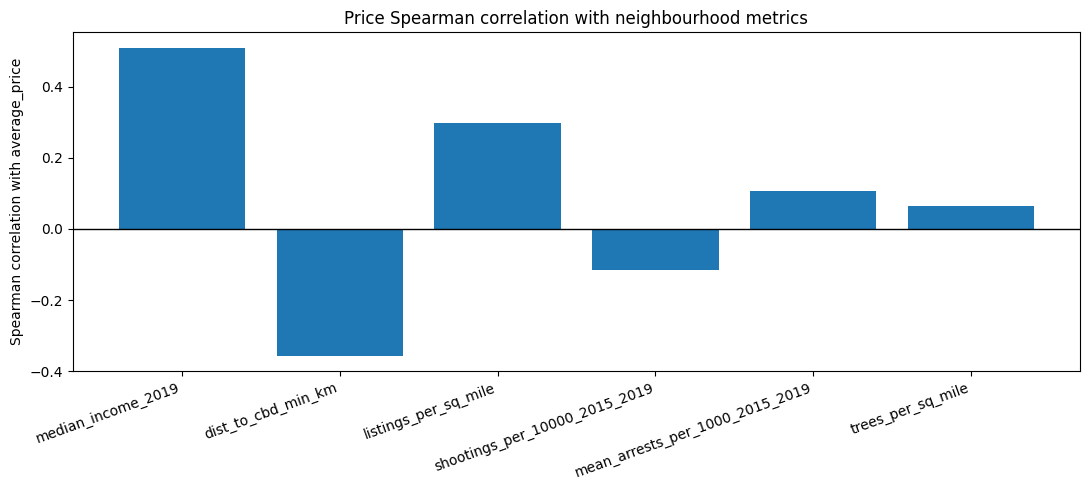

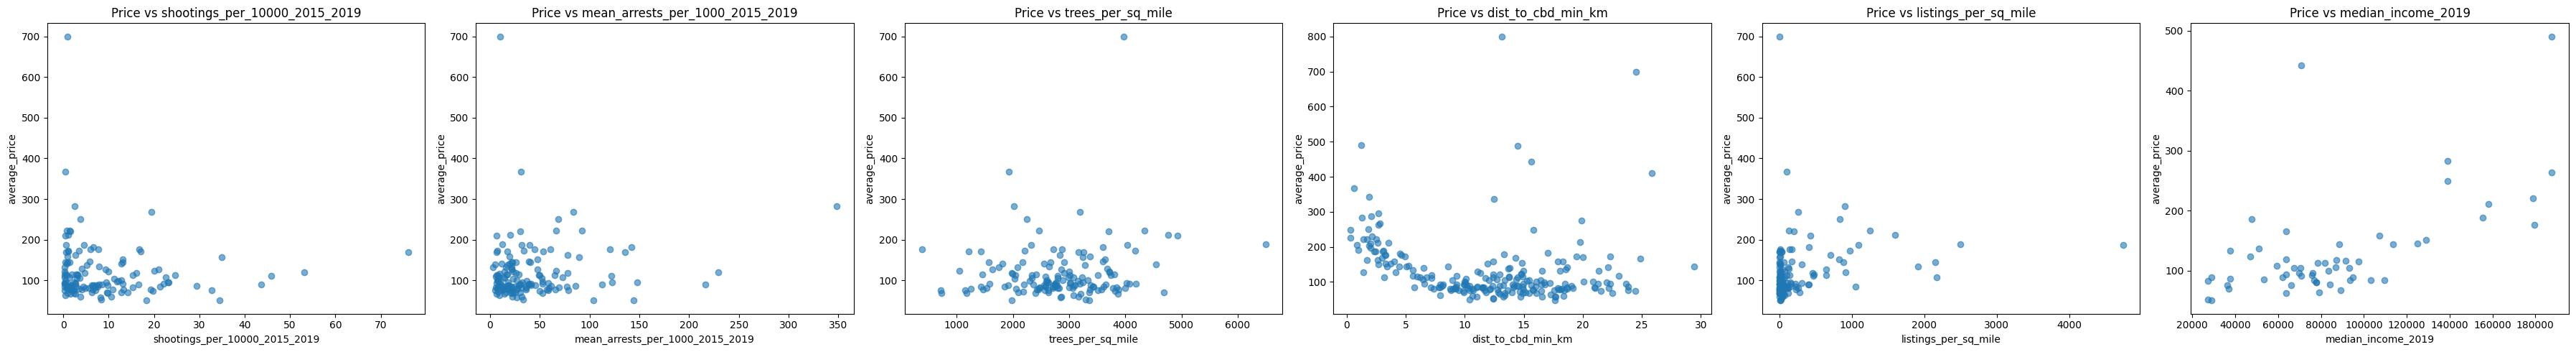

In [ ]:
# Combined correlation view: listing-level + neighbourhood-level
 # 1) Listing-level: price vs distance to CBD
listing_level_df = airbnb_nyc_df[['price', 'dist_to_cbd_min_km']].copy()
listing_level_df['price'] = pd.to_numeric(listing_level_df['price'], errors='coerce')
listing_level_df['dist_to_cbd_min_km'] = pd.to_numeric(listing_level_df['dist_to_cbd_min_km'], errors='coerce')
listing_level_df = listing_level_df.dropna().copy()

listing_cbd_corr_summary = pd.DataFrame([
    {
        'variable': 'dist_to_cbd_min_km (listing-level)',
        'spearman_corr_with_price': listing_level_df['price'].corr(listing_level_df['dist_to_cbd_min_km'], method='spearman'),
        'rows_used': len(listing_level_df),
    }
])

print('Listing-level Spearman correlation: price vs dist_to_cbd_min_km')
display(listing_cbd_corr_summary)

# 2) Neighbourhood-level: raw average price vs neighbourhood metrics
# Add listing density: listings_per_sq_mile.
listing_density_df = (
    airbnb_nyc_df[['neighbourhood']]
    .dropna(subset=['neighbourhood'])
    .copy()
)
listing_density_df['neighbourhood'] = listing_density_df['neighbourhood'].apply(clean_neighbourhood_keep_coop)
listing_density_df = (
    listing_density_df
    .groupby('neighbourhood', as_index=False)
    .size()
    .rename(columns={'size': 'listing_count'})
)

listing_density_df = listing_density_df.merge(
    neighborhood_area_df[['neighbourhood', 'area_sq_miles']],
    on='neighbourhood',
    how='inner',
)
listing_density_df = listing_density_df[listing_density_df['area_sq_miles'] > 0].copy()
listing_density_df['listings_per_sq_mile'] = (
    listing_density_df['listing_count'] / listing_density_df['area_sq_miles']
)

corr_source = neighbourhood_combined_metrics.merge(
    cbd_distance_by_neighbourhood,
    on='neighbourhood',
    how='left',
).merge(
    listing_density_df[['neighbourhood', 'listings_per_sq_mile']],
    on='neighbourhood',
    how='left',
).merge(
    median_income_by_neighbourhood,
    on='neighbourhood',
    how='left',
)

corr_cols = [
    'average_price',
    'shootings_per_10000_2015_2019',
    'mean_arrests_per_1000_2015_2019',
    'trees_per_sq_mile',
    'dist_to_cbd_min_km',
    'listings_per_sq_mile',
    'median_income_2019',
]

corr_df = corr_source[corr_cols].copy()
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')

# Spearman correlations with average price
target = 'average_price'
feature_cols = [c for c in corr_cols if c != target]

corr_summary = pd.DataFrame({
    'variable': feature_cols,
    'spearman_corr_with_price': [corr_df[target].corr(corr_df[c], method='spearman') for c in feature_cols],
})

corr_summary = corr_summary.sort_values('spearman_corr_with_price', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print('Spearman correlation with average_price (neighbourhood level):')
display(corr_summary)

# Bar chart of Spearman correlations
plt.figure(figsize=(11, 5))
plt.bar(corr_summary['variable'], corr_summary['spearman_corr_with_price'])
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Spearman correlation with average_price')
plt.title('Price Spearman correlation with neighbourhood metrics')
plt.tight_layout()
plt.show()

# Scatter plots for each variable against price
fig, axes = plt.subplots(1, len(feature_cols), figsize=(36, 5))
if len(feature_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, feature_cols):
    plot_df = corr_df[[target, col]].dropna()
    ax.scatter(plot_df[col], plot_df[target], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f'Price vs {col}')

plt.tight_layout()
plt.show()